In [1]:
import pandas as pd
import os 
from pathlib import Path
import numpy as np
%matplotlib inline 
import matplotlib.pyplot as plt 
from matplotlib import cm


In [2]:
ccc_path = '/om2/user/imgriff/projects/cocktail_party/datasets/EnglishCCC_v1.2'

In [3]:
ccc_df = pd.read_csv(Path(ccc_path, "confusionCorpus_v1.2.csv"))

In [4]:
ccc_df.head()

,ID,Length,Masker,Onset,SNR,Speaker,Target,Raw,Responses,N-Listeners,Counts,Confusion,Consistency,Target-Arpabet,Target-IPA,Target-frequency,Confusion-Arpabet,Confusion-IPA,Confusion-frequency,Phoneme-distance
0,3784,11520,SSN,104656,-6.982,s3,jointly,drink|drink|drink|drinking|dream|jointly|join|...,drink|jointly|join|enjoyment|drinking|dream,15,9 2 1 1 1 1,drink,9,! JH OY N T . L IY,! dʒ ɔɪ n t . l i,3.10,! D R IH NG K,! d ɹ ɪ ŋ k,5.06,57
1,3786,9172,SSN,455143,-6.173,s3,buyer,fire|buyer|fire|fire|pie|fire|fire|quiet|fire|...,fire|buyer|quiet|pie|prior|final,15,9 2 1 1 1 1,fire,9,! B AY . AX,! b aɪ . ə,4.13,! F AY . AX,! f aɪ . ə,5.18,10
2,3787,13280,SSN,658770,-6.200,s3,sleek,sleek|sleep|sleep|sleek|sleep|sleek|sleep|slee...,sleep|sleek,15,10 5,sleep,10,! S L IY K,! s l i k,3.29,! S L IY P,! s l i p,4.94,10
3,3791,14898,SSN,826266,-5.132,s3,perverse,perverse|averse|traverse|reverse|reverse|perve...,reverse|perverse|averse|traverse,15,8 3 3 1,reverse,8,P AX ! V ER S,p ə ! v ɜ s,3.13,R AX ! V ER S,ɹ ə ! v ɜ s,4.15,20
4,3804,11876,SSN,496159,-5.623,s3,because,curse|because|coat|coast|reverse|coast|coast|c...,coast|coat|because|curse|reverse,15,8 2 2 2 1,coast,8,B IH ! K OH Z,b ɪ ! k ɒ z,6.22,! K OW S T,! k oʊ s t,4.86,41


## Visualize Confusions 

Let's look at the top N many confusions.

First, lets sort the data by Consistency. This will show us words that are confused most often.  

*Note: Target- and Confusion-frequency indicate word occurance for the target and confused word, not the error rate!*

In [6]:
ccc_df.sort_values(by='Consistency', ascending=False,inplace=True)

In [10]:
ccc_df.head(100)

,ID,Length,Masker,Onset,SNR,Speaker,Target,Raw,Responses,N-Listeners,Counts,Confusion,Consistency,Target-Arpabet,Target-IPA,Target-frequency,Confusion-Arpabet,Confusion-IPA,Confusion-frequency,Phoneme-distance
115,4827,11018,SSN,723400,-4.253,s4,loss,lost|lost|lost|lost|lost|lost|lost|lost|lost|l...,lost,16,16,lost,16,! L OH S,! l ɒ s,4.67,! L OH S T,! l ɒ s t,5.42,7
1348,20422,11840,BMN3,57417,-4.556,s3,suit,sweet|sweet|sweet|sweet|sweet|sweet|sweet|swee...,sweet,15,15,sweet,15,! S UW T,! s u t,4.59,! S W IY T,! s w i t,4.98,17
1996,28563,11164,BMN3,376700,-3.786,s2,towel,town|town|town|town|town|town|town|town|town|t...,town,15,15,town,15,! T AW . AX L,! t aʊ . ə l,3.87,! T AW N,! t aʊ n,5.24,17
2251,31587,10560,BAB4,669477,-1.667,s4,monarch,peace|peace|piece|peace|peace|peace|peace|peac...,peace,15,15,peace,15,! M OH . N AX K,! m ɒ . n ə k,3.85,! P IY S,! p i s,4.74,44
405,8163,9920,BAB4,61834,-1.094,s2,placed,place|place|place|place|place|place|place|plac...,place,15,15,place,15,! P L EY S T,! p l eɪ s t,4.40,! P L EY S,! p l eɪ s,5.78,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,15159,7942,BAB4,846978,-1.808,s4,yeah,hatred|patron|patron|patron|patron|hateful|pat...,patron|hatred|hateful,15,13 1 1,patron,13,! Y EA,! j ɛə,6.27,! P EY . T R AX N,! p eɪ . t ɹ ə n,3.61,48
1037,16449,9000,BMN3,586675,-5.609,s3,pill,hill|hill|hill|hill|hill|pill|hill|kill|hill|h...,hill|kill|pill,15,13 1 1,hill,13,! P IH L,! p ɪ l,3.81,! HH IH L,! h ɪ l,4.71,10
3067,41875,12096,BAB4,348340,-1.903,s3,aged,age|age|age|age|age|age|age|age|age|age|age|ch...,age|chair,14,13 1,age,13,! EY JH D,! eɪ dʒ d,4.30,! EY JH,! eɪ dʒ,5.18,7
887,14601,12448,BAB4,837977,-2.435,s1,contain,juice|juice|juice|juice|juice|juice|juice|juic...,juice|puce,14,13 1,juice,13,K AX N ! T EY N,k ə n ! t eɪ n,4.14,! JH UW S,! dʒ u s,4.44,51


In [8]:
ccc_df[['Target', 'Confusion']].head(50)

,Target,Confusion
115,loss,lost
1348,suit,sweet
1996,towel,town
2251,monarch,peace
405,placed,place
2704,lacking,lucky
337,after,actor
2486,sixteenth,sixteen
768,stated,seated
769,tape,take


In [7]:
ccc_df.Responses.iloc[:100].str.split("|").explode()

115        lost
1996       town
1107      sweet
2604     seated
1992    peasant
         ...   
1835      brown
1835    browned
1835     branch
2189      crack
2189       crap
Name: Responses, Length: 198, dtype: object

In [8]:
top_n_targerts = 100

target_words = ccc_df.Target.iloc[:top_n_targerts]
responses =  ccc_df.Responses.iloc[:top_n_targerts].str.split("|").explode()

unique_words = pd.concat([target_words, responses]).unique()

# unique_target = ccc_df.Target.iloc[:100].unique()
# # unique_words = pd.unique(ccc_df[['Target', 'Confusion']].values.ravel('K'))
# unique_responses = ccc_df.Responses.iloc[:100].str.split("|").explode().unique()
# # unique_responses = [word for word in unique_responses if word in unique_target]
# unique_words = np.unique(np.hstack([unique_target, unique_responses]))



n_unique = len(unique_words)

In [9]:
unique_words

array(['loss', 'towel', 'suit', 'stated', 'driver', 'tape', 'after',
       'lacking', 'placed', 'monarch', 'sixteenth', 'eighteenth',
       'sergeant', 'compare', 'midday', 'childhood', 'acute', 'slab',
       'studied', 'herald', 'travelled', 'boon', 'aged', 'distress',
       'crew', 'channel', 'bull', 'junk', 'silky', 'asset', 'hook', 'odd',
       'stool', 'nuisance', 'gold', 'naughty', 'such', 'insight',
       'factor', 'calmly', 'cheek', 'ticking', 'childish', 'mortar',
       'jug', 'leisure', 'wicket', 'west', 'wake', 'bazaar', 'reel',
       'minute', 'via', 'letter', 'bride', 'parting', 'wallet', 'bunk',
       'skilled', 'riot', 'ranch', 'likewise', 'clothes', 'dawn', 'novel',
       'letting', 'replace', 'touched', 'smiling', 'lap', 'striped',
       'declared', 'strained', 'shilling', 'running', 'turf', 'treat',
       'share', 'juice', 'fuss', 'aloud', 'fake', 'fifty', 'road',
       'coast', 'brow', 'cracked', 'lost', 'town', 'sweet', 'seated',
       'peasant', 'take

In [10]:
n_unique, ccc_df.shape

(225, (3207, 20))

In [11]:
word_ixs = {word:ix for ix, word in enumerate(unique_words)}
ixs_map = {ix:word for word,ix in word_ixs.items()}

In [13]:
confusion_mat = np.zeros((n_unique, n_unique))
for ix, row in ccc_df.iloc[:50].iterrows():
    if row.Target not in word_ixs:
        continue
    target_ix = word_ixs[row.Target]
    response_ixs = [word_ixs[word] for word in row.Responses.split('|') if word in unique_words]
    counts = [int(count) for count in row.Counts.split()[:len(response_ixs)]]
    confusion_mat[target_ix, response_ixs] = counts

    

## Sort confusions by most common

In [14]:
ccc_df.Target.values

array(['loss', 'towel', 'suit', ..., 'cry', 'thou', 'banner'],
      dtype=object)

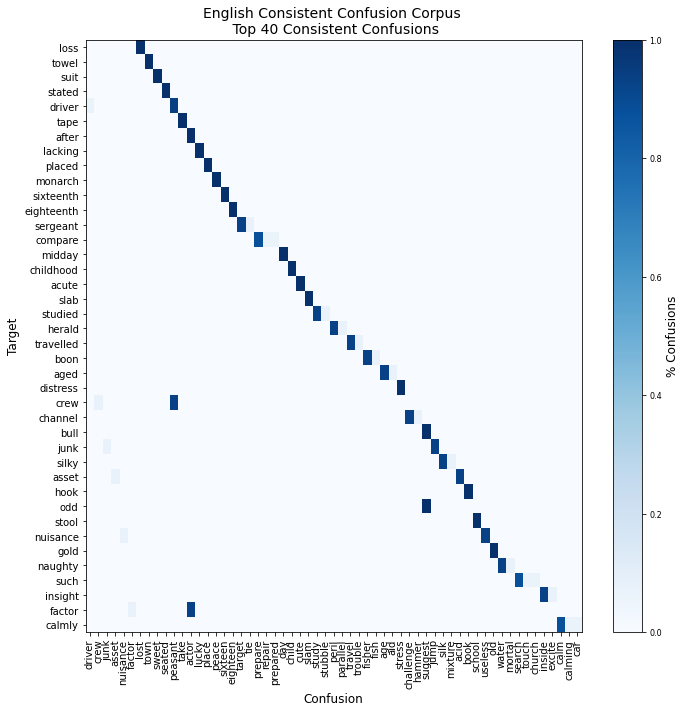

In [16]:
plt.figure(figsize=(10,10))
n_to_plot = 40


col_ixs = np.where(confusion_mat[:n_to_plot,:].any(axis=0))[0]
conf = confusion_mat[:n_to_plot,col_ixs]
conf = conf / conf.sum(1).reshape(-1,1)

plt.imshow(conf, vmin=0, cmap=cm.Blues, aspect='auto');
clb=plt.colorbar()
clb.ax.tick_params(labelsize=8) 
clb.ax.set_ylabel('% Confusions',fontsize=12)

plt.xticks(np.arange(len(col_ixs)), unique_words[col_ixs], rotation=90, fontsize=10);
plt.yticks(np.arange(n_to_plot), unique_words[:n_to_plot], fontsize=10);
plt.title(f'English Consistent Confusion Corpus \n Top {n_to_plot} Consistent Confusions', fontsize=14);
plt.ylabel('Target', fontsize=12);
plt.xlabel('Confusion', fontsize=12);
plt.tight_layout()